In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadbeh_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 100
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

# Load training data

In [5]:
import numpy as np
root = 'preprocessed_data/'+train_folder[0]
x_k_train, y_k_train = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_train, y_t_train = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_train, y_c_train = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_train, y_g_train = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')

In [6]:
y_t = y_t_train
count_pos, count_neg = 0, 0
for label in y_t:
    if label == [1.0]:
        count_pos+=1
    else:
        count_neg+=1
print('Negative class is minority class')
print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
print('Number of sample deficit: {0}'.format(str(count_pos-count_neg)))

Negative class is minority class
Imbalance ratio: 0.58:0.42
Number of sample deficit: 3979


# predict each val fold's FC output

In [7]:
from model_evaluation.model_predictions import predict_graph, predict_1dcnn_addfeatures, predict_gru
import numpy as np

In [34]:
from sklearn.model_selection import StratifiedKFold
import torch
def get_val_probs(predict_model, model_folder, X_data, y_data, is_m2 = False, g_data = None, c_data_sizes=None):
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    val_preds = []
    val_gts = []
    ensemble_fcs = []
    Stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=ran_2)
    
    for i, (train_index, val_index) in enumerate(Stratified_kfold.split(X_data, y_data)):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        
        X_val, y_val = X_data[val_index], y_data[val_index]
#         X_val = torch.FloatTensor(X_val).to(device)
        val_gts.append(y_val)
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_val, device, 'f1').cpu().detach()#FC_outputs: outputs of the last FC
        else:
            g_val = g_data[val_index]
            g_data_size = g_val.shape
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_val, g_val, device, 'f1').to('cpu')
        
        probs = torch.sigmoid(FC_outputs)
        preds = torch.round(probs)
        val_preds.append(preds)
        ensemble_fcs.append(FC_outputs)
    return ensemble_fcs, val_preds, val_gts

In [35]:
model_folder = "best_val_f1/"
ensemble_x1, val_preds_x1, val_gts_x1 = get_val_probs(predict_graph, model_folder, x_k_train, y_k_train)
ensemble_x1 = torch.cat(ensemble_x1, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [36]:
ensemble_x3, val_preds_x3, val_gts_x3 = get_val_probs(predict_1dcnn_addfeatures, model_folder, x_t_train, y_t_train)
ensemble_x3 = torch.cat(ensemble_x3, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [37]:
c_data_sizes = [(16, 1), (16, 1)]
ensemble_x2, val_preds_x2, val_gts_x2 = get_val_probs(predict_gru, model_folder, x_c_train, y_c_train, True, x_g_train, c_data_sizes)
ensemble_x2 = torch.cat(ensemble_x2, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4899, 16, 2]) torch.Size([4899, 2])
torch.Size([9798, 16, 1]) torch.Size([4899, 2])


In [38]:
val_preds_x1 = torch.cat(val_preds_x1, axis=0)
val_preds_x2 = torch.cat(val_preds_x2, axis=0)
val_preds_x3 = torch.cat(val_preds_x3, axis=0)

In [39]:
val_gts_x1 = np.concatenate(val_gts_x1, axis=0)
val_gts_x2 = np.concatenate(val_gts_x2, axis=0)
val_gts_x3 = np.concatenate(val_gts_x3, axis=0)

In [40]:
def acc(preds, targets):
    train_corrects = 0
    train_corrects += (preds == targets).sum().item()
    acc = train_corrects/len(targets)
    return acc

In [41]:
acc(np.array(val_preds_x1), val_gts_x1)

0.8836687211722928

In [42]:
acc(np.array(val_preds_x2.detach().numpy()), val_gts_x2)

0.8352993999755092

In [43]:
acc(np.array(val_preds_x3), val_gts_x3)

0.7652557247234582

# split (FC_output: x1, x2, x3 also called lv1 features) Data again to Train/Val 

In [44]:
import numpy as np
from sklearn.model_selection import train_test_split

In [45]:
ran_3 = 70
test_ratio=0.2
X_train_x1, X_val_x1, y_train_x1, y_val_x1 = train_test_split(ensemble_x1, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x2, X_val_x2, y_train_x2, y_val_x2 = train_test_split(ensemble_x2, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x3, X_val_x3, y_train_x3, y_val_x3 = train_test_split(ensemble_x3, val_gts_x1, test_size=test_ratio, random_state=ran_3)

In [46]:
print(X_train_x1.shape, X_train_x2.shape, X_train_x3.shape, y_train_x1.shape)

torch.Size([19599, 1]) torch.Size([19599, 1]) torch.Size([19599, 1]) (19599, 1)


# Train ensemble learning - on lv1 features

In [47]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

alpha = count_imbalance(y_train_x1)

Negative class is minority class
Imbalance ratio: 0.58:0.42
Number of sample deficit: 3151


In [48]:
import os
import torch 
import numpy as np
# import utils.data_loader as Dataset
from torch.utils.data import DataLoader, Dataset
import models.ensemble_ablation as EAB 
# import models.onedcnn_model_second as onedcnn_model_second
# torch.backends.cudnn.enabled=False

In [41]:
save_model_folder_acc, save_model_folder_f1 = 'training_results/best_val_acc/ablation/', 'training_results/best_val_f1/ablation/'

if not os.path.exists(save_model_folder_acc):
    os.mkdir(save_model_folder_acc)

if not os.path.exists(save_model_folder_f1):
    os.mkdir(save_model_folder_f1)

In [42]:
class leveloneData(Dataset):
    
    def __init__(self, X1_data, X2_data, X3_data, y_data):
        self.X1_data = X1_data
        self.X2_data = X2_data
        self.X3_data = X3_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        return self.X1_data[index], self.X2_data[index], self.X3_data[index], self.y_data[index]
        
    def __len__ (self):
        return len(self.y_data)

[INFO]: Epoch 2 of 100
Training loss: 0.279, training acc: 88.000
Validation loss: 0.262, validation acc: 90.000

Best validation acc: 90.0

Saving best model for epoch: 2


Best validation f1: 0.89

Saving best model for epoch: 2

[INFO]: Epoch 3 of 100
Training loss: 0.246, training acc: 90.000
Validation loss: 0.232, validation acc: 91.000

Best validation acc: 91.0

Saving best model for epoch: 3


Best validation f1: 0.91

Saving best model for epoch: 3

[INFO]: Epoch 4 of 100
Training loss: 0.220, training acc: 91.000
Validation loss: 0.212, validation acc: 92.000

Best validation acc: 92.0

Saving best model for epoch: 4


Best validation f1: 0.92

Saving best model for epoch: 4

[INFO]: Epoch 5 of 100
Training loss: 0.204, training acc: 92.000
Validation loss: 0.197, validation acc: 93.000

Best validation acc: 93.0

Saving best model for epoch: 5

[INFO]: Epoch 6 of 100
Training loss: 0.192, training acc: 93.000
Validation loss: 0.187, validation acc: 93.000

Best validation f

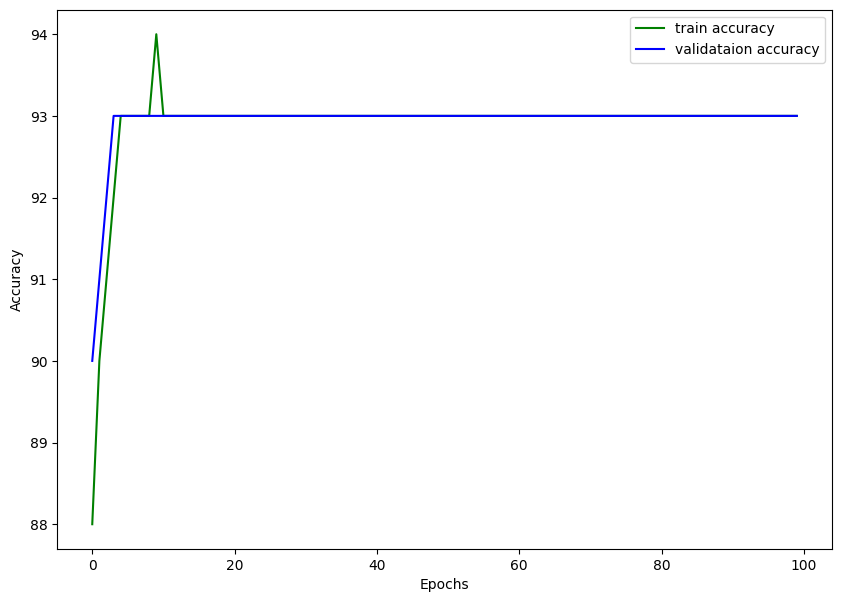

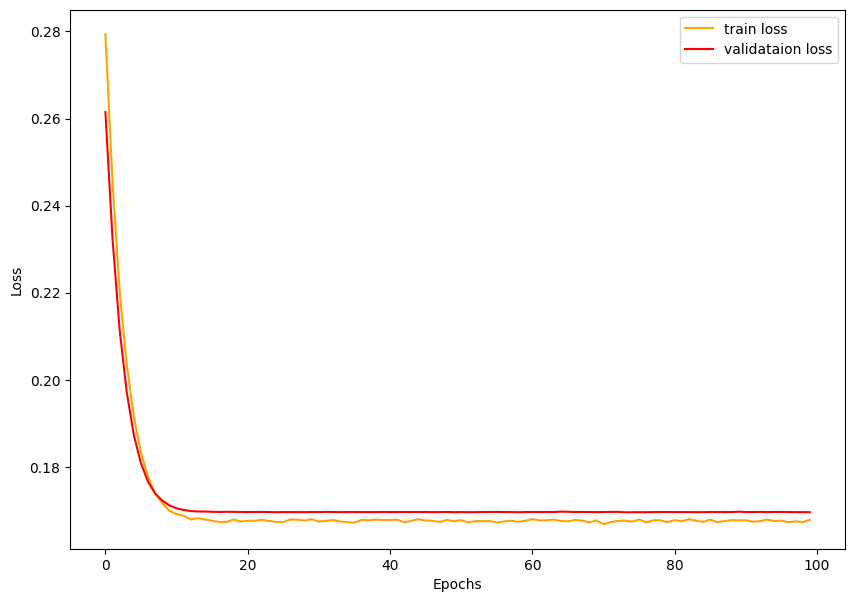

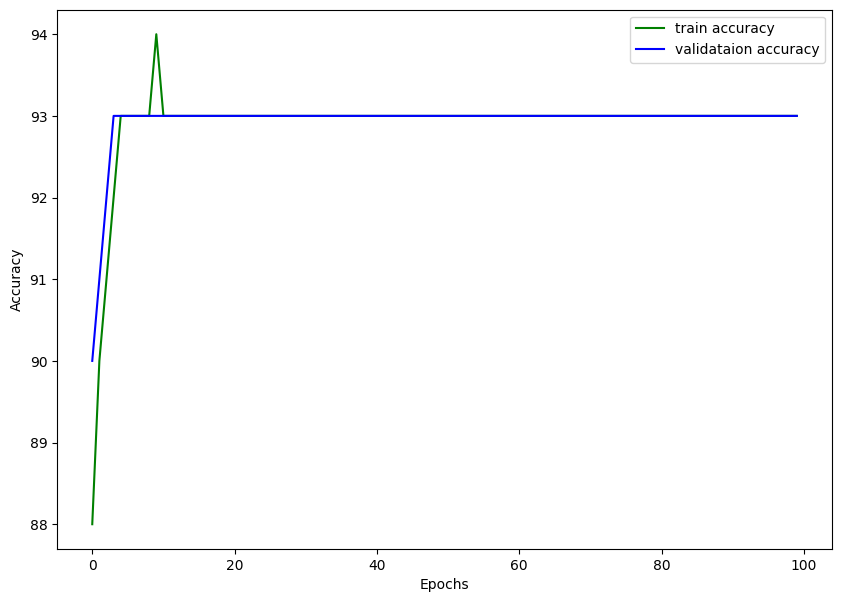

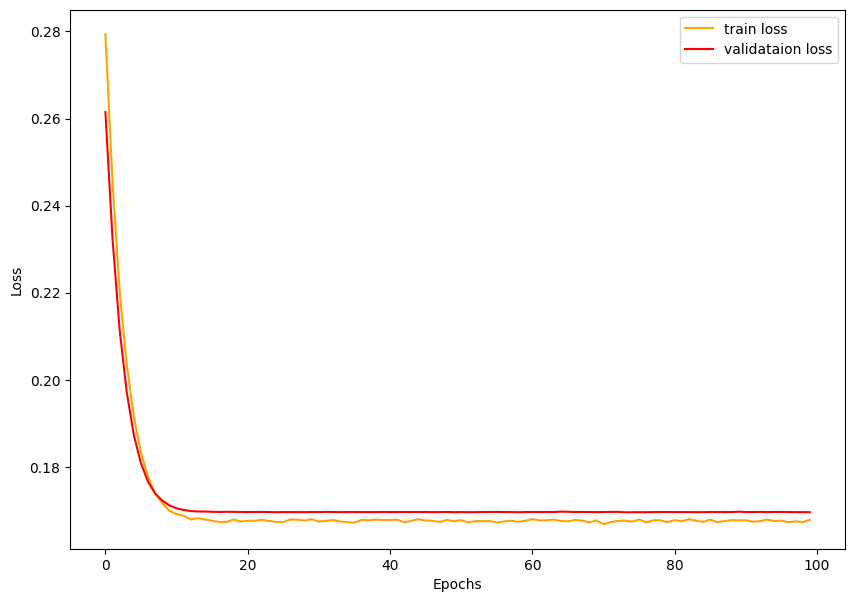

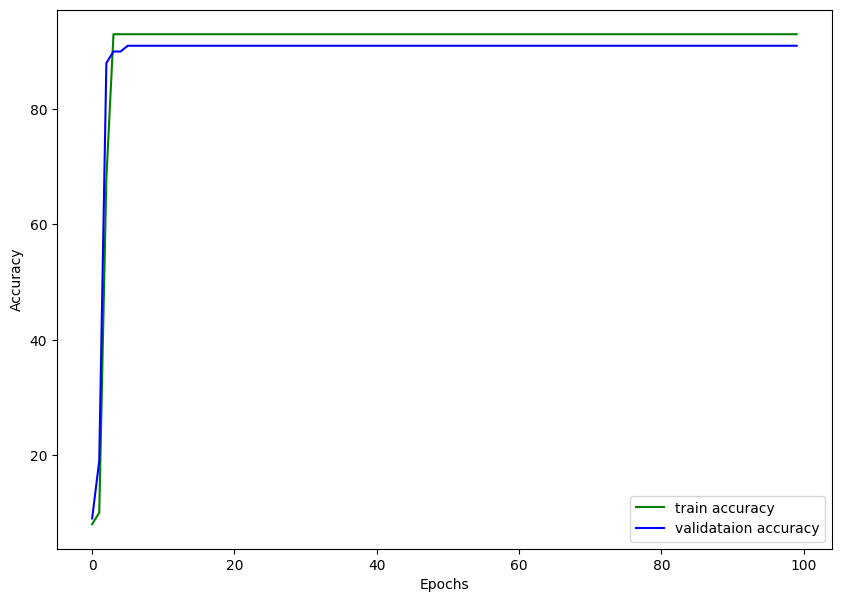

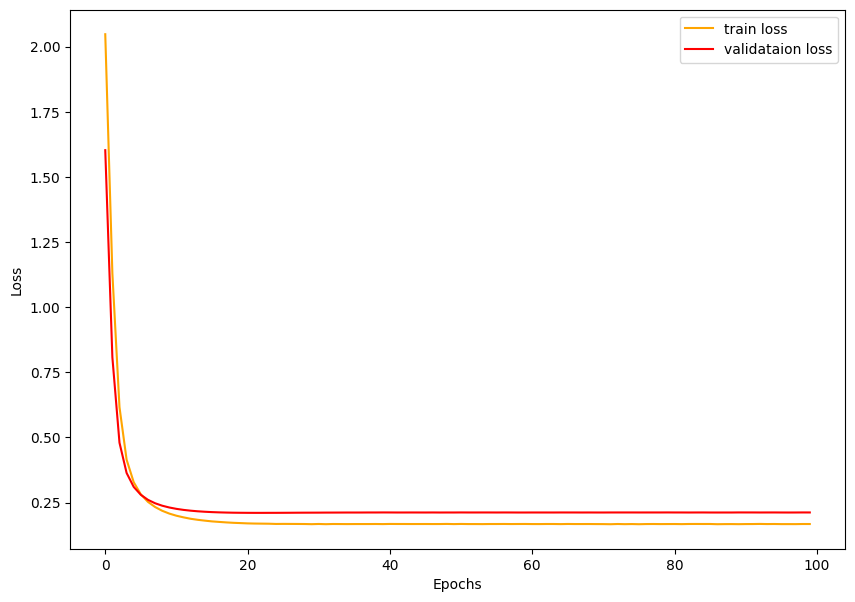

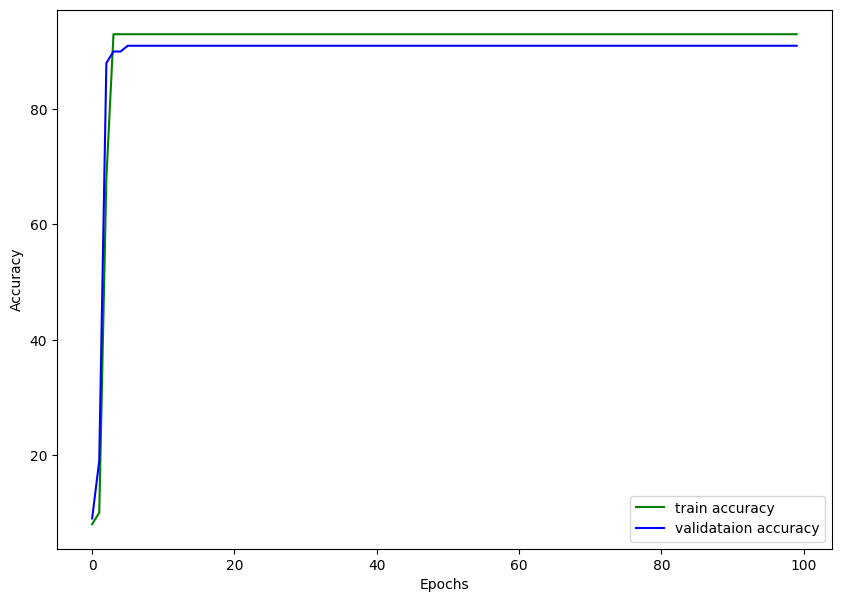

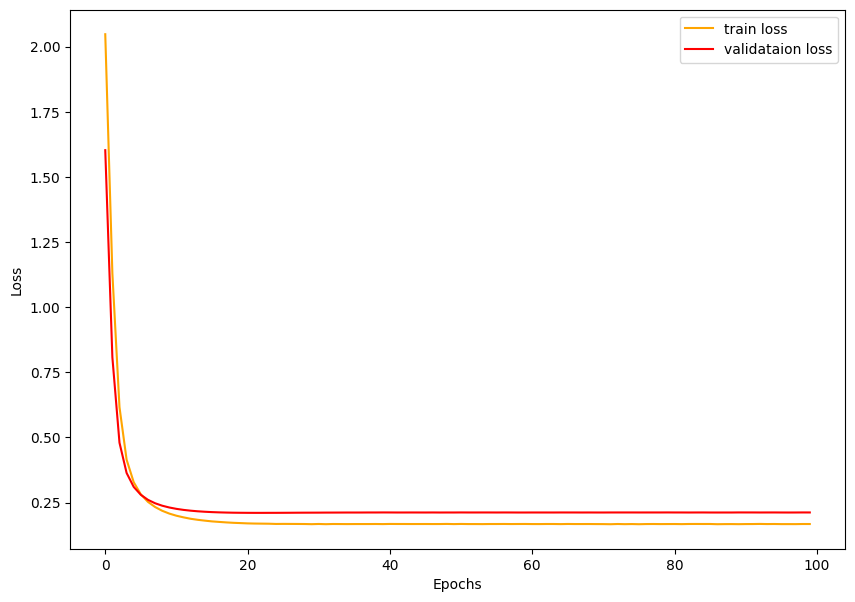

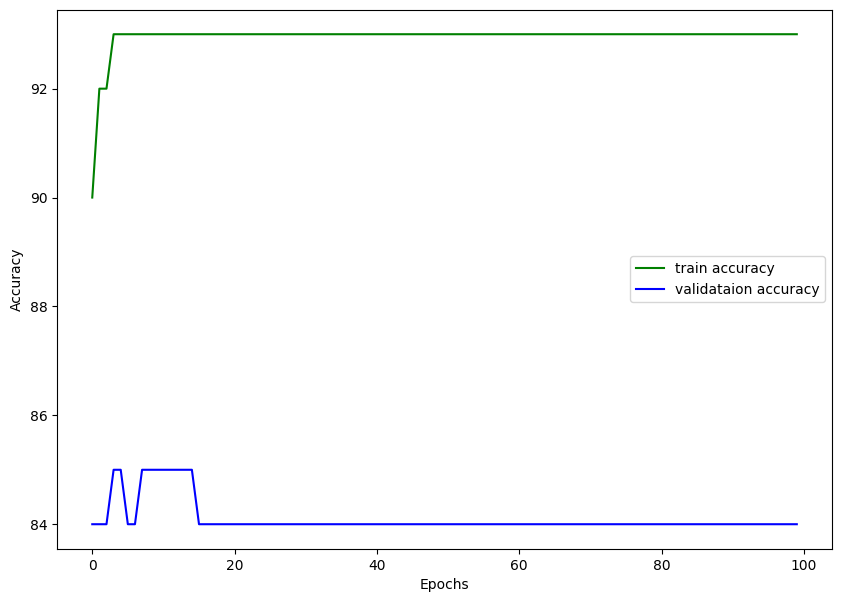

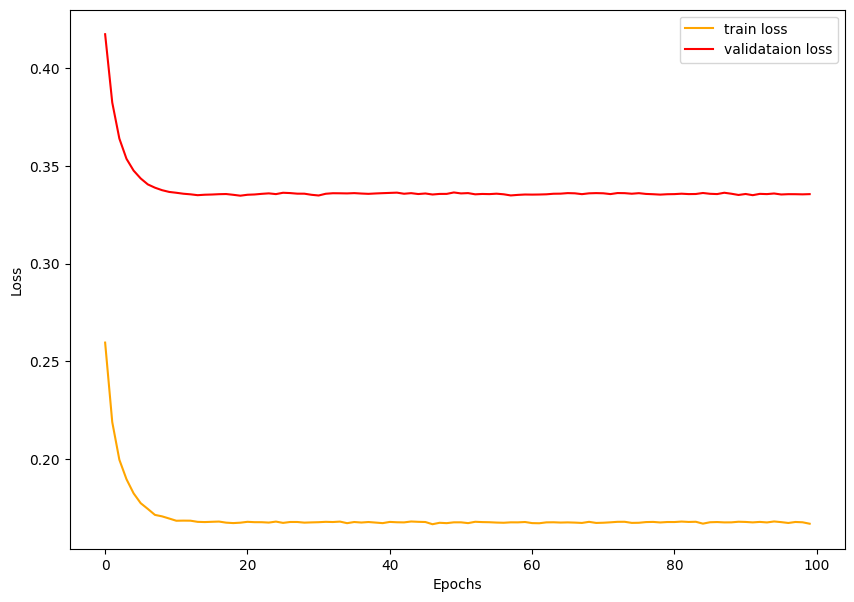

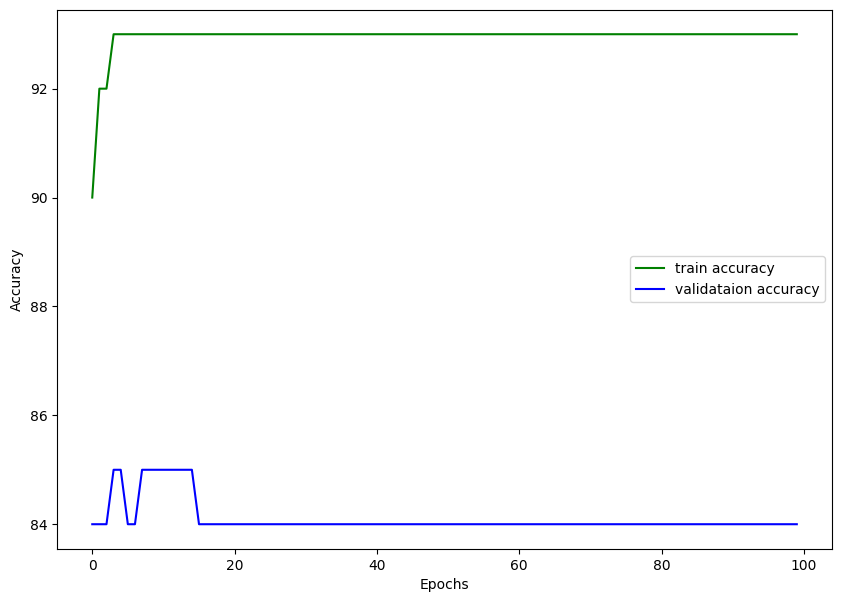

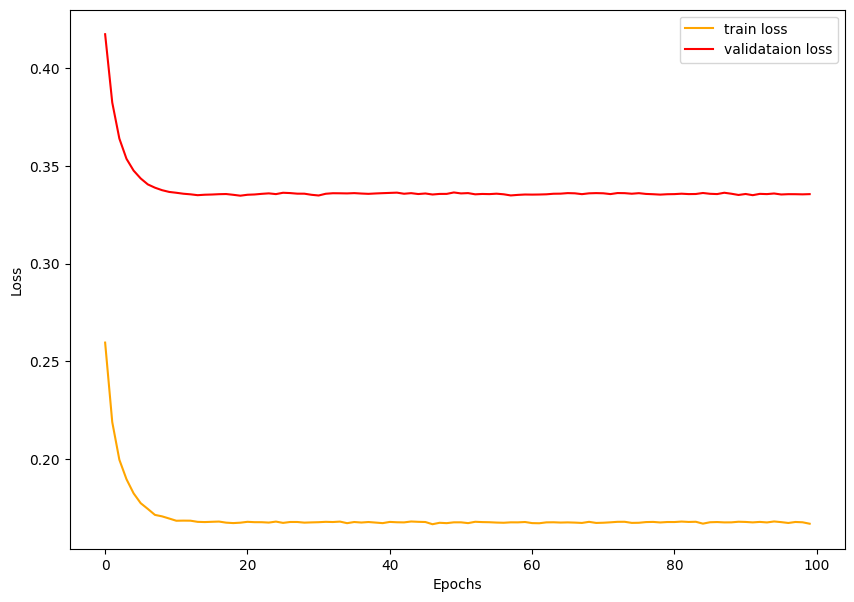

In [43]:
# torch.backends.cudnn.enabled = False
p_sets = [['x1', 'x2'],
          ['x1', 'x3'],
          ['x2', 'x3']]

for p_set in p_sets:
    p1, p2 = p_set[0], p_set[1]
    save_model_acc = save_model_folder_acc+'{0}_{1}/'.format(p1, p2)
    save_model_f1 = save_model_folder_f1+'{0}_{1}/'.format(p1, p2)

    if not os.path.exists(save_model_acc):
        os.mkdir(save_model_acc)

    if not os.path.exists(save_model_f1):
        os.mkdir(save_model_f1)

    
    train_data = leveloneData(torch.FloatTensor(X_train_x1.detach()),torch.FloatTensor(X_train_x2.detach()), torch.FloatTensor(X_train_x3.detach()), torch.FloatTensor(y_train_x1))
    val_data = leveloneData(torch.FloatTensor(X_val_x1.detach()),torch.FloatTensor(X_val_x2.detach()),torch.FloatTensor(X_val_x3.detach()),  torch.FloatTensor(y_val_x1))

    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
    val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)

    EAB.train_perceptron_ablations(train_loader, val_loader, save_model_acc, save_model_f1, loss_name, p1, p2)

# Test on testset
* (1) we have 5-fold models in each pipeline model (i.e, Graph, GRU, 1dcnn)
* (2) we predict FC_output for our X_test using all 5x3pipelines models.
* (3) we multiply y_test for 5 times as well to match number of samples in (2)
* (4) from (2) we collect ensemble_x and from (3) we collect new y_test
* (5) we test ensemble learner on ensemble_x and calculate its performance stats by comparing ground truth labels new y_test

In [18]:
def get_test_prob(predict_model, model_folder, X_test, is_m2 = False, g_data = None, c_data_sizes=None):
    folds = 5
    ensemble_test = []
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')   
    for i in range(folds):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_test, device, 'f1').cpu().detach()
        else:
            g_data_size = g_data.shape
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_test, g_data, device, 'f1').to('cpu').detach()
        ensemble_test.append(FC_outputs)
    return ensemble_test
    

In [19]:
root = 'preprocessed_data/jaadbeh_with_c_g/test/'
x_k_test, y_k_test = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_test, y_t_test = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_test, y_c_test = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_test, y_g_test = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')
print(len(y_k_test))

18790


In [20]:
import torch
model_folder = 'best_val_f1/'
c_data_sizes = [(16, 1), (16, 1)]
ensemble_test_k=get_test_prob(predict_graph, model_folder, x_k_test)
ensemble_test_s=get_test_prob(predict_gru, model_folder, x_c_test, True, x_g_test, c_data_sizes)
ensemble_test_t=get_test_prob(predict_1dcnn_addfeatures, model_folder, x_t_test)

torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)
/data/home/acw607

In [21]:
ensemble_test_k = np.concatenate(ensemble_test_k,axis=0)
ensemble_test_s = np.concatenate(ensemble_test_s,axis=0)
ensemble_test_t = np.concatenate(ensemble_test_t,axis=0)
ensemble_x_test = np.concatenate([ensemble_test_k, ensemble_test_s, ensemble_test_t], axis=1)
print(ensemble_x_test.shape)

(93950, 3)


In [22]:
# ensemble_x_test.cpu()

In [23]:
y_test = np.concatenate([y_k_test]*5, axis=0)
y_test.shape

(93950, 1)

In [24]:
model_folder

'best_val_f1/'

# macro

In [25]:
from models import ensemble_ablation as EA
def predict_ensemble_ablation(model_folder, x, device, best_by):
    if not best_by:
        model_path = model_folder+'best_ablation_model.pth'
    else:
        model_path = model_folder+'best_ablation_model_{0}.pth'.format('by'+best_by)
        
    model = EA.Perceptron_ablation().to(device)
    x = torch.FloatTensor(x).to(device)
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    y_hat = model(x)
    return y_hat 

In [26]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
import torch
from torchmetrics.functional import precision_recall
from torchmetrics import F1Score, AUROC
from torchmetrics.classification import BinaryAUROC

def get_precision_recall_F1_v2(preds, targets, probs, which_class=1): 
    """
    This function uses sklearn library
    The func does not support confidence threshold feature, i.e, we can't calculate scores by adjusting a confidence level threshold.
    The func only report positive class results for (p,r,f1), unless pos_label is specified. 
    However, by default, auc is the unweighted mean of all classes (treated the same) 
    
    """
#     preds, targets, probs =  preds.cpu().data.numpy(), targets.cpu().data.numpy(),probs.cpu().data.numpy()
    p = precision_score(targets, preds, pos_label=which_class, average='binary')
    r = recall_score(targets, preds, pos_label=which_class, average='binary')
    f1 = f1_score(targets, preds, pos_label=which_class, average='binary')
    targets,probs= targets.squeeze(),probs.squeeze()
    auc = roc_auc_score(targets,probs) 
    return "{:.2f}".format(p), "{:.2f}".format(r), "{:.2f}".format(f1),  "{:.2f}".format(auc)

In [27]:
from model_evaluation.performance_scores import get_precision_recall_F1, calculate_acc
import matplotlib.pyplot as plt
from sklearn import metrics
def test_ablation(test_k_fc, test_s_fc, test_t_fc, test_gts, model_folder, p1, p2, best_by, which_class=None, show_performance_stats=True):
    if p1 == 'x1':
        if p2 == 'x2':
            x_test_fc = np.concatenate((test_k_fc, test_s_fc), 1)
        elif p2 == 'x3':
            x_test_fc = np.concatenate((test_k_fc, test_t_fc), 1)
    elif p1 == 'x2':
        x_test_fc = np.concatenate((test_s_fc, test_t_fc), 1)
    else:
        raise SystemExit()
    model_folder = model_folder+p1+'_'+p2+'/'
    print('Testing model: {0}_{1}'.format(p1, p2))
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    FC_outputs = predict_ensemble_ablation(model_folder, x_test_fc, device, best_by).cpu().detach() 
    probs = torch.sigmoid(FC_outputs)
    preds = torch.round(probs)
    
    preds = preds.numpy()

    acc=calculate_acc(preds, test_gts)
    if show_performance_stats:
        if which_class==None:
            p,re,f1,auc = get_precision_recall_F1(preds=preds, targets=test_gts, probs=probs)
        else:
            p,re,f1,auc = get_precision_recall_F1_v2(preds, test_gts, probs, which_class=which_class)

        if which_class==None:
            print('confidence: ')
            probs = probs.cpu().detach().numpy()
            probs_li = np.squeeze(probs).tolist()
            plt.hist(probs_li)
            plt.show()
            print('confusion matrix: ')
            preds = preds.astype(int)
            preds_li = np.squeeze(preds).tolist()
            confusion_matrix = metrics.confusion_matrix(test_gts,preds, normalize='true')
            cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['NotCross', 'Crossing'])
            cm_display.plot()
            plt.show()

        print('acc: {:.2f}'.format(acc))
        print('auc: {0:.2f}'.format(float(auc)))
        print('f1: {0:.2f}'.format(float(f1)))
        print('pr: {0:.2f}'.format(float(p)))
        print('re: {0:.2f}'.format(float(re)))

        print("="*40)
    else:
        pass

    y_li = test_gts.tolist()
    preds = preds.tolist()
    test_gts = test_gts.tolist()
    return probs_li, preds_li, y_li

In [28]:
ensemble_test_k.shape

(93950, 1)

# macro

In [53]:
model_folder = 'training_results/best_val_f1/ablation/'

Testing model: x1_x2
confidence: 


/tmp/ipykernel_3360551/1732870223.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


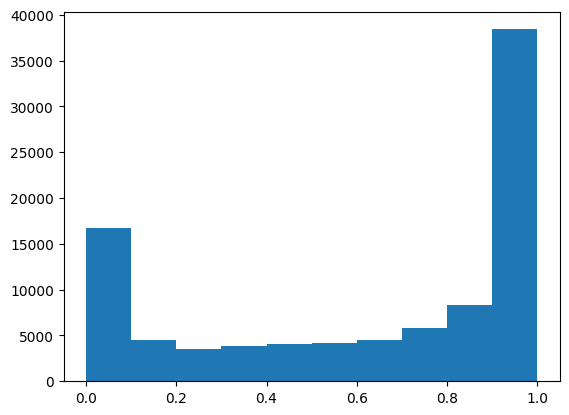

confusion matrix: 


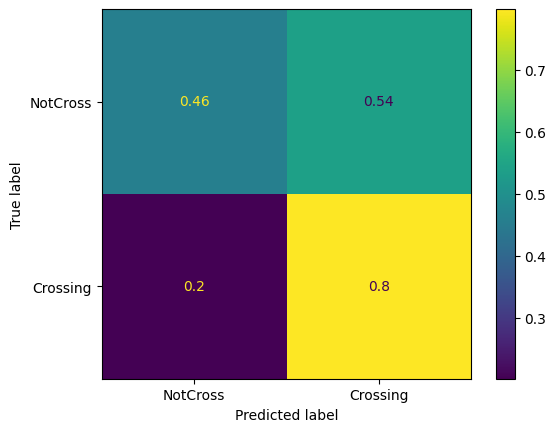

acc: 0.60
auc: 0.68
f1: 0.60
pr: 0.64
re: 0.63
Testing model: x1_x3
confidence: 


/tmp/ipykernel_3360551/1732870223.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


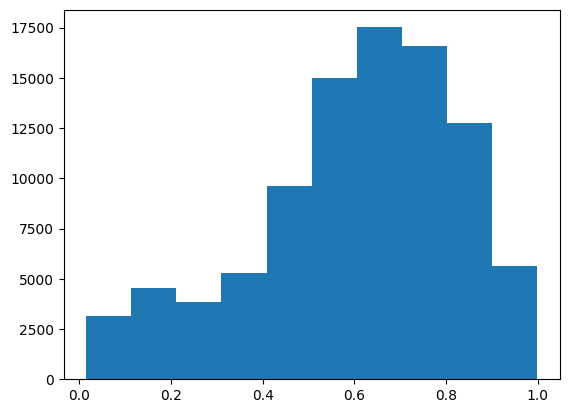

confusion matrix: 


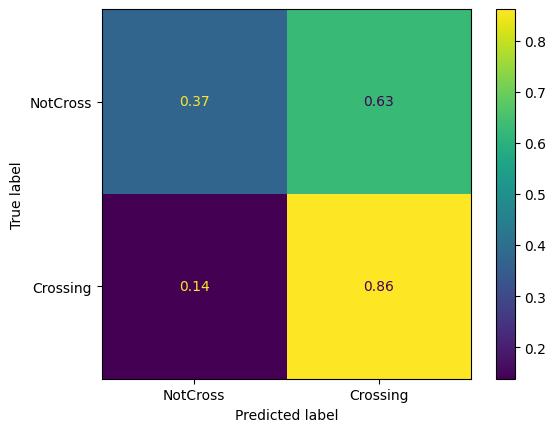

acc: 0.58
auc: 0.68
f1: 0.57
pr: 0.65
re: 0.62
Testing model: x2_x3
confidence: 


/tmp/ipykernel_3360551/1732870223.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


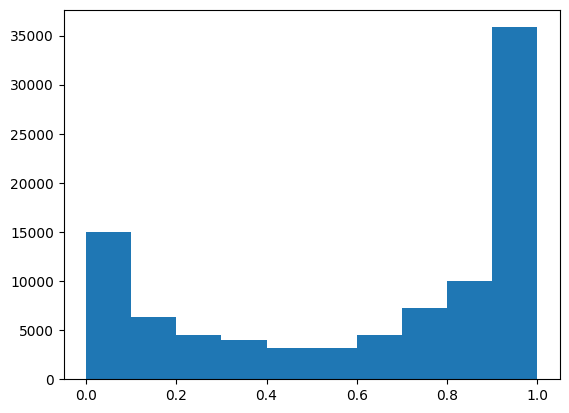

confusion matrix: 


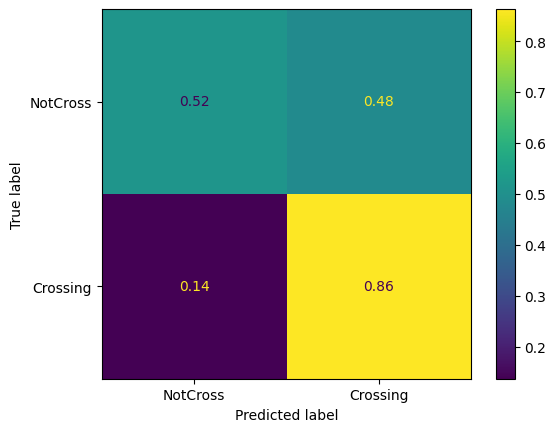

acc: 0.67
auc: 0.74
f1: 0.66
pr: 0.70
re: 0.69


In [54]:
best_by = 'f1'
p_sets = [['x1', 'x2'],
          ['x1', 'x3'],
          ['x2', 'x3']]

import json
with open('JAADbeh_results.json', 'r') as f:
    results = json.load(f)
    

for p_set in p_sets:
    p1, p2 = p_set[0], p_set[1]
    probs_li, preds_li, y_li = test_ablation(ensemble_test_k, ensemble_test_s, ensemble_test_t, y_test, model_folder, p1, p2, best_by, which_class=None)
    results[p_set[0]+'_'+p_set[1]] = {'probs':probs_li, 'preds': preds_li, 'test_gts': y_li}





In [55]:
with open('JAADbeh_results.json', 'w') as f:
    json.dump(results, f)